### 1. Import Packages

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import seaborn as sns

### 2. Data Availability

In [5]:
import os
os.chdir('C:\\Users\\ACER\Desktop\\python practice\\Python GGN MAY24 _ Class 17 Python for Data Science (GGN) MAY 2024')

In [6]:
df = pd.read_csv('cust_seg - 1655553015951 - 1720278065736.csv')
df.head()

,custid,sex,AqChannel,region,Marital_status,segment,pre_usage,Post_usage_1month,Latest_mon_usage,post_usage_2ndmonth
0,70,0,4,1,1,1,57,52,49.2,57.2
1,121,1,4,2,1,3,68,59,63.6,64.9
2,86,0,4,3,1,1,44,33,64.8,36.3
3,141,0,4,3,1,3,63,44,56.4,48.4
4,172,0,4,2,1,2,47,52,68.4,57.2


### 3. EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   custid               200 non-null    int64  
 1   sex                  200 non-null    int64  
 2   AqChannel            200 non-null    int64  
 3   region               200 non-null    int64  
 4   Marital_status       200 non-null    int64  
 5   segment              200 non-null    int64  
 6   pre_usage            200 non-null    int64  
 7   Post_usage_1month    200 non-null    int64  
 8   Latest_mon_usage     200 non-null    float64
 9   post_usage_2ndmonth  200 non-null    float64
dtypes: float64(2), int64(8)
memory usage: 15.8 KB


In [5]:
df.sex.value_counts()

sex
1    109
0     91
Name: count, dtype: int64

In [6]:
df.region.value_counts()

region
2    95
3    58
1    47
Name: count, dtype: int64

In [7]:
df.segment.value_counts()

segment
2    105
3     50
1     45
Name: count, dtype: int64

### Q1. Card usage has been improved significantly from last year usage which was 50.

**1. Define H0 and Ha.**  
         
                     H0 : mean <= 50
         
                     Ha : mean > 50




**2.  At CI = 95% ,**

                      alpha value (significance level) = 0.05


**3. Perform the test.**

                      We have to perform t-test here.

In [8]:
pop_mean = 50

In [9]:
_, p_value = stats.ttest_1samp(df.Post_usage_1month,popmean = pop_mean, alternative = 'greater')

**4. Rejection Rule:**

In [10]:
if p_value > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

reject H0


Since, p value is less than 0.05 we will reject H0.

**5. Business Conclusion:**
                           
                    Credit card usage has been improved significantly from last year usage => spending power has increased

### Q2. The campaign was successful in terms of credit card usage.

**1. Define H0 and Ha.**  
         
                     H0 : mean_post_usage <= mean_pre_usage
         
                     Ha : mean_post_usage > mean_pre_usage




**2.  At CI = 95% ,**

                      alpha value (significance level) = 0.05


**3. Perform the test.**

                      We have to perform t-test here.

In [11]:
_,p_value1 = stats.ttest_rel(df.pre_usage, df.Post_usage_1month, alternative='greater')

In [12]:
if p_value1 > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

fail to reject H0


In [13]:
_,p_value2 = stats.ttest_rel(df.pre_usage, df.post_usage_2ndmonth, alternative='greater')

In [14]:
if p_value2 > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

fail to reject H0


In [15]:
_,p_value3 = stats.ttest_rel(df.pre_usage, df.Latest_mon_usage, alternative='greater')

In [16]:
if p_value3 > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

fail to reject H0


**4. Rejection Rule:**

Since for all samples p_value is less than alpha value , hence, we fail to reject H0.

**5. Business Conclusion:**
                           
                    Based on the given samples we conclude that campaign isn't successful. 

### Q3. Is there any difference between males & females in terms of credit card usage ?

In [18]:
male_usage = df.loc[df.sex==0,'pre_usage']
female_usage = df.loc[df.sex==1,'pre_usage']

**1. Define H0 and Ha.**  
         
                     H0 : credit card usage of male = credit card usage of female
         
                     Ha : credit card usage of male != credit card usage of female




**2.  At CI = 95% ,**

                      alpha value (significance level) = 0.05


**3. Perform the test.**

                      We have to perform t-test --> independent.

In [20]:
_, p_value = stats.ttest_ind(male_usage, female_usage)

**4. Rejection Rule:**

In [21]:
if p_value > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

fail to reject H0


**5. Business Conclusion:**
                           
                    There is no difference in credit card usage between male and female.

### Q4. Difference between segments of the customers in terms of credit card usage.

In [4]:
# extracting all samples i.e credit card usage for each segment.
s1 = df.loc[df.segment == 1, 'pre_usage']
s2 = df.loc[df.segment == 2, 'pre_usage']
s3 = df.loc[df.segment == 3, 'pre_usage']

In [5]:
print('Mean credit card usage of segment 1 = ',s1.mean())
print('Mean credit card usage of segment 2 = ',s2.mean())
print('Mean credit card usage of segment 3 = ',s3.mean())

Mean credit card usage of segment 1 =  49.75555555555555
Mean credit card usage of segment 2 =  56.161904761904765
Mean credit card usage of segment 3 =  46.2


**1. Define H0 and Ha.**  
         
                     H0 : mean1 = mean2 = mean3
         
                     Ha : mean1 != mean2 != mean3




**2.  At CI = 95% ,**

                      alpha value (significance level) = 0.05


**3. Perform the test.**

                      We have to perform f-test ( annova test)

In [7]:
_, p_value = stats.f_oneway(s1,s2,s3)

**4. Rejection Rule:**

In [8]:
if p_value > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

reject H0


**5. Business Conclusion:**
                           
                    There is no difference in credit card usage between male and female.

### Q5. Is there any relation between Region & Segment?

In [9]:
df.region.value_counts()

region
2    95
3    58
1    47
Name: count, dtype: int64

In [10]:
df.segment.value_counts()

segment
2    105
3     50
1     45
Name: count, dtype: int64

In [13]:
# observed frequency table
obs = pd.crosstab(index=df.region,columns=df.segment)
obs

segment,1,2,3
region,,,
1,16,19,12
2,20,44,31
3,9,42,7


**1. Define H0 and Ha.**  
         
                     H0 : Region and Segment are independent variables.
         
                     Ha : Region and Segment are dependent variables.




**2.  At CI = 95% ,**

                      alpha value (significance level) = 0.05


**3. Perform the test.**

                      We have to perform chi-square test.

In [15]:
_,p_value,_,_ = stats.chi2_contingency(obs)

**4. Rejection Rule:**

In [16]:
if p_value > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

reject H0


**5. Business Conclusion:**
                           
                    Region and Segment are dependent variables.

### Q6. Is there any relationship between card usage in the latest month and pre usage of campaign ?

<Axes: xlabel='pre_usage', ylabel='Latest_mon_usage'>

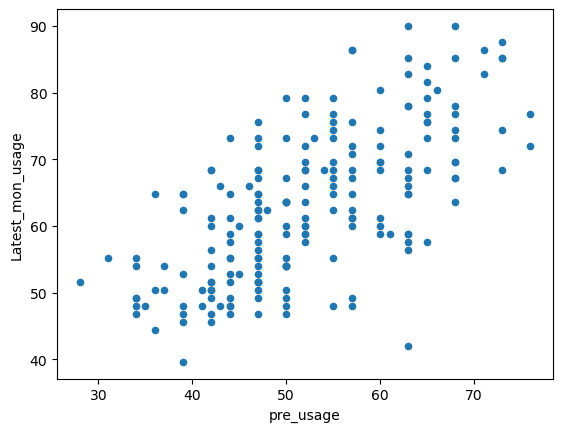

In [17]:
df.plot(x='pre_usage',y='Latest_mon_usage',kind='scatter')

**1. Define H0 and Ha.**  
         
                     H0 : There is no relation between latest month usage and pre usage
         
                     Ha : There is a relation between latest month usage and pre usage.




**2.  At CI = 95% ,**

                      alpha value (significance level) = 0.05


**3. Perform the test.**

                      We have to perform pearsonr test.

In [19]:
_,p_value = stats.pearsonr(df.pre_usage,df.Latest_mon_usage)

**4. Rejection Rule:**

In [20]:
if p_value > 0.05:
    print('fail to reject H0')
else:
    print('reject H0')

reject H0


**5. Business Conclusion:**

                             There is a relation between latest month usage and pre campaign usage.